# A Small Two-Stage Production Plan

A plant chooses regular production before demand is known. After demand is observed, it may use expensive emergency production or dispose of surplus inventory.

This example is deliberately small enough to inspect by hand before studying larger stochastic programs.

## Learning goals

* Separate first-stage production from scenario-dependent recourse.
* Put recourse variables and constraints in scenario `Block`s.
* Check scenario probabilities and balance equations.
* Compute RP, EEV, WS, VSS, and EVPI.
* Interpret a capacity-sensitivity calculation.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pyomo.environ as pyo

PRODUCTS = ["A", "B"]
SCENARIOS = ["low", "likely", "high"]
PROBABILITY = {"low": 0.25, "likely": 0.50, "high": 0.25}
DEMAND = {
    ("low", "A"): 20, ("low", "B"): 25,
    ("likely", "A"): 35, ("likely", "B"): 40,
    ("high", "A"): 60, ("high", "B"): 70,
}
REGULAR_COST = {"A": 20, "B": 28}
EMERGENCY_COST = {"A": 55, "B": 65}
DISPOSAL_COST = {"A": 4, "B": 6}
HOURS = {"A": 2, "B": 1}
CAPACITY = 100

assert abs(sum(PROBABILITY.values()) - 1) < 1e-12
assert all(EMERGENCY_COST[p] > REGULAR_COST[p] for p in PRODUCTS)
SOLVER = pyo.SolverFactory("appsi_highs")
assert SOLVER.available(exception_flag=False), 'Install HiGHS before running this notebook.'

## Model

Regular production $x_p$ is shared across scenarios. In scenario $s$, emergency production $e_{sp}$ and disposal $w_{sp}$ satisfy

$$x_p + e_{sp} - w_{sp} = d_{sp}.$$

The objective minimizes regular cost plus expected recourse cost. Positive disposal cost prevents making product only to discard it.

In [2]:
def build_model(demand=DEMAND, probability=PROBABILITY, capacity=CAPACITY):
    m = pyo.ConcreteModel()
    m.P = pyo.Set(initialize=PRODUCTS, ordered=True)
    m.S = pyo.Set(initialize=list(probability), ordered=True)
    m.probability = pyo.Param(m.S, initialize=probability)
    m.regular = pyo.Var(m.P, domain=pyo.NonNegativeReals)
    m.capacity = pyo.Constraint(
        expr=sum(HOURS[p] * m.regular[p] for p in m.P) <= capacity
    )

    def scenario_rule(block, scenario):
        block.emergency = pyo.Var(m.P, domain=pyo.NonNegativeReals)
        block.disposal = pyo.Var(m.P, domain=pyo.NonNegativeReals)
        block.balance = pyo.Constraint(
            m.P,
            rule=lambda block, product: (
                m.regular[product] + block.emergency[product]
                - block.disposal[product] == demand[scenario, product]
            ),
        )
        block.recourse_cost = pyo.Expression(
            expr=sum(
                EMERGENCY_COST[p] * block.emergency[p]
                + DISPOSAL_COST[p] * block.disposal[p] for p in m.P
            )
        )

    m.scenario = pyo.Block(m.S, rule=scenario_rule)
    m.regular_cost = pyo.Expression(
        expr=sum(REGULAR_COST[p] * m.regular[p] for p in m.P)
    )
    m.expected_recourse_cost = pyo.Expression(
        expr=sum(m.probability[s] * m.scenario[s].recourse_cost for s in m.S)
    )
    m.objective = pyo.Objective(
        expr=m.regular_cost + m.expected_recourse_cost, sense=pyo.minimize
    )
    return m

def solve(model):
    result = SOLVER.solve(model)
    assert pyo.check_optimal_termination(result), result.solver.termination_condition
    return model

def regular_plan(model):
    return {p: float(pyo.value(model.regular[p])) for p in model.P}

recourse_model = solve(build_model())
print("regular plan:", regular_plan(recourse_model))
print("expected cost:", round(pyo.value(recourse_model.objective), 2))

regular plan: {'A': 30.0, 'B': 40.0}
expected cost: 2790.0


## Inspect every scenario

Do not trust the objective alone. Verify that every scenario balances and that recourse responds in the expected direction.

In [3]:
rows = []
for s in recourse_model.S:
    block = recourse_model.scenario[s]
    for p in recourse_model.P:
        regular = pyo.value(recourse_model.regular[p])
        emergency = pyo.value(block.emergency[p])
        disposal = pyo.value(block.disposal[p])
        residual = regular + emergency - disposal - DEMAND[s, p]
        assert abs(residual) <= 1e-7
        rows.append({
            "scenario": s, "product": p, "regular": regular,
            "emergency": emergency, "disposal": disposal, "demand": DEMAND[s, p],
        })
pd.DataFrame(rows).set_index(["scenario", "product"]).round(2)

regular  emergency  disposal  demand
scenario product                                      
low      A           30.0        0.0      10.0      20
         B           40.0        0.0      15.0      25
likely   A           30.0        5.0       0.0      35
         B           40.0        0.0       0.0      40
high     A           30.0       30.0       0.0      60
         B           40.0       30.0       0.0      70

## Value of stochastic and perfect information

For this minimization problem:

* **RP** is the optimal two-stage expected cost.
* **EEV** evaluates the mean-demand plan across all scenarios.
* **WS** averages independent perfect-information plans.
* $\mathrm{VSS}=EEV-RP$.
* $\mathrm{EVPI}=RP-WS$.

Therefore $WS\le RP\le EEV$.

In [4]:
def fixed_plan_cost(plan, demand=DEMAND, probability=PROBABILITY, capacity=CAPACITY):
    model = build_model(demand, probability, capacity)
    for p, value in plan.items():
        model.regular[p].fix(value)
    return float(pyo.value(solve(model).objective))

rp = float(pyo.value(recourse_model.objective))
mean_demand = {
    ("mean", p): sum(PROBABILITY[s] * DEMAND[s, p] for s in SCENARIOS)
    for p in PRODUCTS
}
mean_model = solve(build_model(mean_demand, {"mean": 1.0}))
eev = fixed_plan_cost(regular_plan(mean_model))

ws = 0.0
for s in SCENARIOS:
    scenario_demand = {(s, p): DEMAND[s, p] for p in PRODUCTS}
    perfect_model = solve(build_model(scenario_demand, {s: 1.0}))
    ws += PROBABILITY[s] * pyo.value(perfect_model.objective)

tol = 1e-6
assert ws <= rp + tol <= eev + tol
metrics = pd.Series(
    {"RP": rp, "EEV": eev, "WS": ws, "VSS": eev - rp, "EVPI": rp - ws},
    name="expected cost [$]",
)
metrics.to_frame().round(2)

,expected cost [$]
RP,2790.00
EEV,2888.91
WS,2456.25
VSS,98.91
EVPI,333.75


## Capacity sensitivity

Capacity is a first-stage resource. Re-solving over a small grid shows where another regular-production hour has value and where the plan becomes insensitive to capacity.

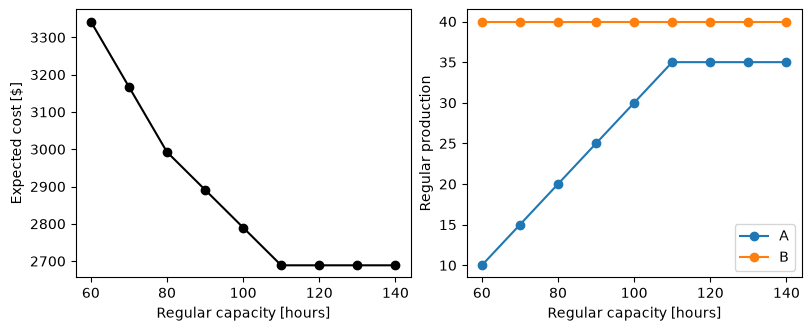

,expected cost,A,B
capacity,,,
60,3342.50,10.0,40.0
70,3167.50,15.0,40.0
80,2992.50,20.0,40.0
90,2891.25,25.0,40.0
100,2790.00,30.0,40.0
110,2688.75,35.0,40.0
120,2688.75,35.0,40.0
130,2688.75,35.0,40.0
140,2688.75,35.0,40.0


In [5]:
capacity_rows = []
for capacity in range(60, 141, 10):
    model = solve(build_model(capacity=capacity))
    capacity_rows.append({
        "capacity": capacity, "expected cost": pyo.value(model.objective),
        **regular_plan(model),
    })
capacity_results = pd.DataFrame(capacity_rows).set_index("capacity")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2), layout="constrained")
capacity_results["expected cost"].plot(ax=axes[0], marker="o", color="black")
capacity_results[PRODUCTS].plot(ax=axes[1], marker="o")
axes[0].set(xlabel="Regular capacity [hours]", ylabel="Expected cost [$]")
axes[1].set(xlabel="Regular capacity [hours]", ylabel="Regular production")
plt.show()
capacity_results.round(2)

## Interpret

1. Which decisions are made before demand is known?
2. In which scenarios does the plan use emergency production or disposal?
3. Why do VSS and EVPI have different signs than in a profit-maximization model?
4. Which product receives scarce regular capacity first, and which tradeoff explains that choice?
5. What modeling detail would you add before using this plan in practice?